
# 07 — Final Profile Interpretation and Decision Support

This notebook presents the final behavioral profiles, representative
trajectories, Tianjin metadata interpretation, and the operational-attention
matrix.

Metadata variables were not clustering inputs.


In [1]:

from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"

profile_summary = pd.read_csv(TABLES / "stage7_profile_summary.csv")
profile_medians = pd.read_csv(TABLES / "stage7_profile_medians.csv")
robust_scores = pd.read_csv(TABLES / "stage7_profile_robust_scores.csv")
violation = pd.read_csv(
    TABLES / "stage7_tianjin_violation_rate_by_profile.csv"
)
attention = pd.read_csv(TABLES / "stage7_decision_support_matrix.csv")
representatives = pd.read_csv(
    TABLES / "stage7_representative_trajectories.csv"
)

profile_summary


,profile_id,profile_name,trajectory_count,percentage,mean_speed_mps,max_speed_mps,speed_std_mps,mean_long_acc_mps2,max_acceleration_mps2,max_deceleration_mps2,acceleration_std_mps2,mean_abs_jerk_mps3,observed_stop_transition_count,stopped_time_ratio
0,1,Smooth and Steady,7477,37.482454,6.727166,9.368795,1.195745,0.151793,0.993201,0.799482,0.489474,0.436295,0.0,0.000000
1,2,Stop-and-Go,6866,34.419491,2.081679,9.882946,2.928115,0.077738,1.789831,1.721508,0.649127,0.360635,1.0,0.590874
2,3,Dynamic Speed Adjustment,4338,21.746541,6.625349,10.863837,2.097874,0.246765,1.955210,1.926502,0.967754,0.780429,0.0,0.000000
3,4,Acceleration-Intensive,1267,6.351514,6.706837,10.704903,1.910059,0.358235,6.843118,2.184274,1.529067,1.111171,0.0,0.000000



## 1. Profile signatures

The table below uses original physical units. The heatmap expresses each
profile median relative to the overall median and IQR.


In [2]:

profile_medians


,profile_id,profile_name,mean_speed_mps,max_speed_mps,speed_std_mps,mean_long_acc_mps2,max_acceleration_mps2,max_deceleration_mps2,acceleration_std_mps2,mean_abs_jerk_mps3,observed_stop_transition_count,stopped_time_ratio
0,1,Smooth and Steady,6.727166,9.368795,1.195745,0.151793,0.993201,0.799482,0.489474,0.436295,0.0,0.000000
1,2,Stop-and-Go,2.081679,9.882946,2.928115,0.077738,1.789831,1.721508,0.649127,0.360635,1.0,0.590874
2,3,Dynamic Speed Adjustment,6.625349,10.863837,2.097874,0.246765,1.955210,1.926502,0.967754,0.780429,0.0,0.000000
3,4,Acceleration-Intensive,6.706837,10.704903,1.910059,0.358235,6.843118,2.184274,1.529067,1.111171,0.0,0.000000


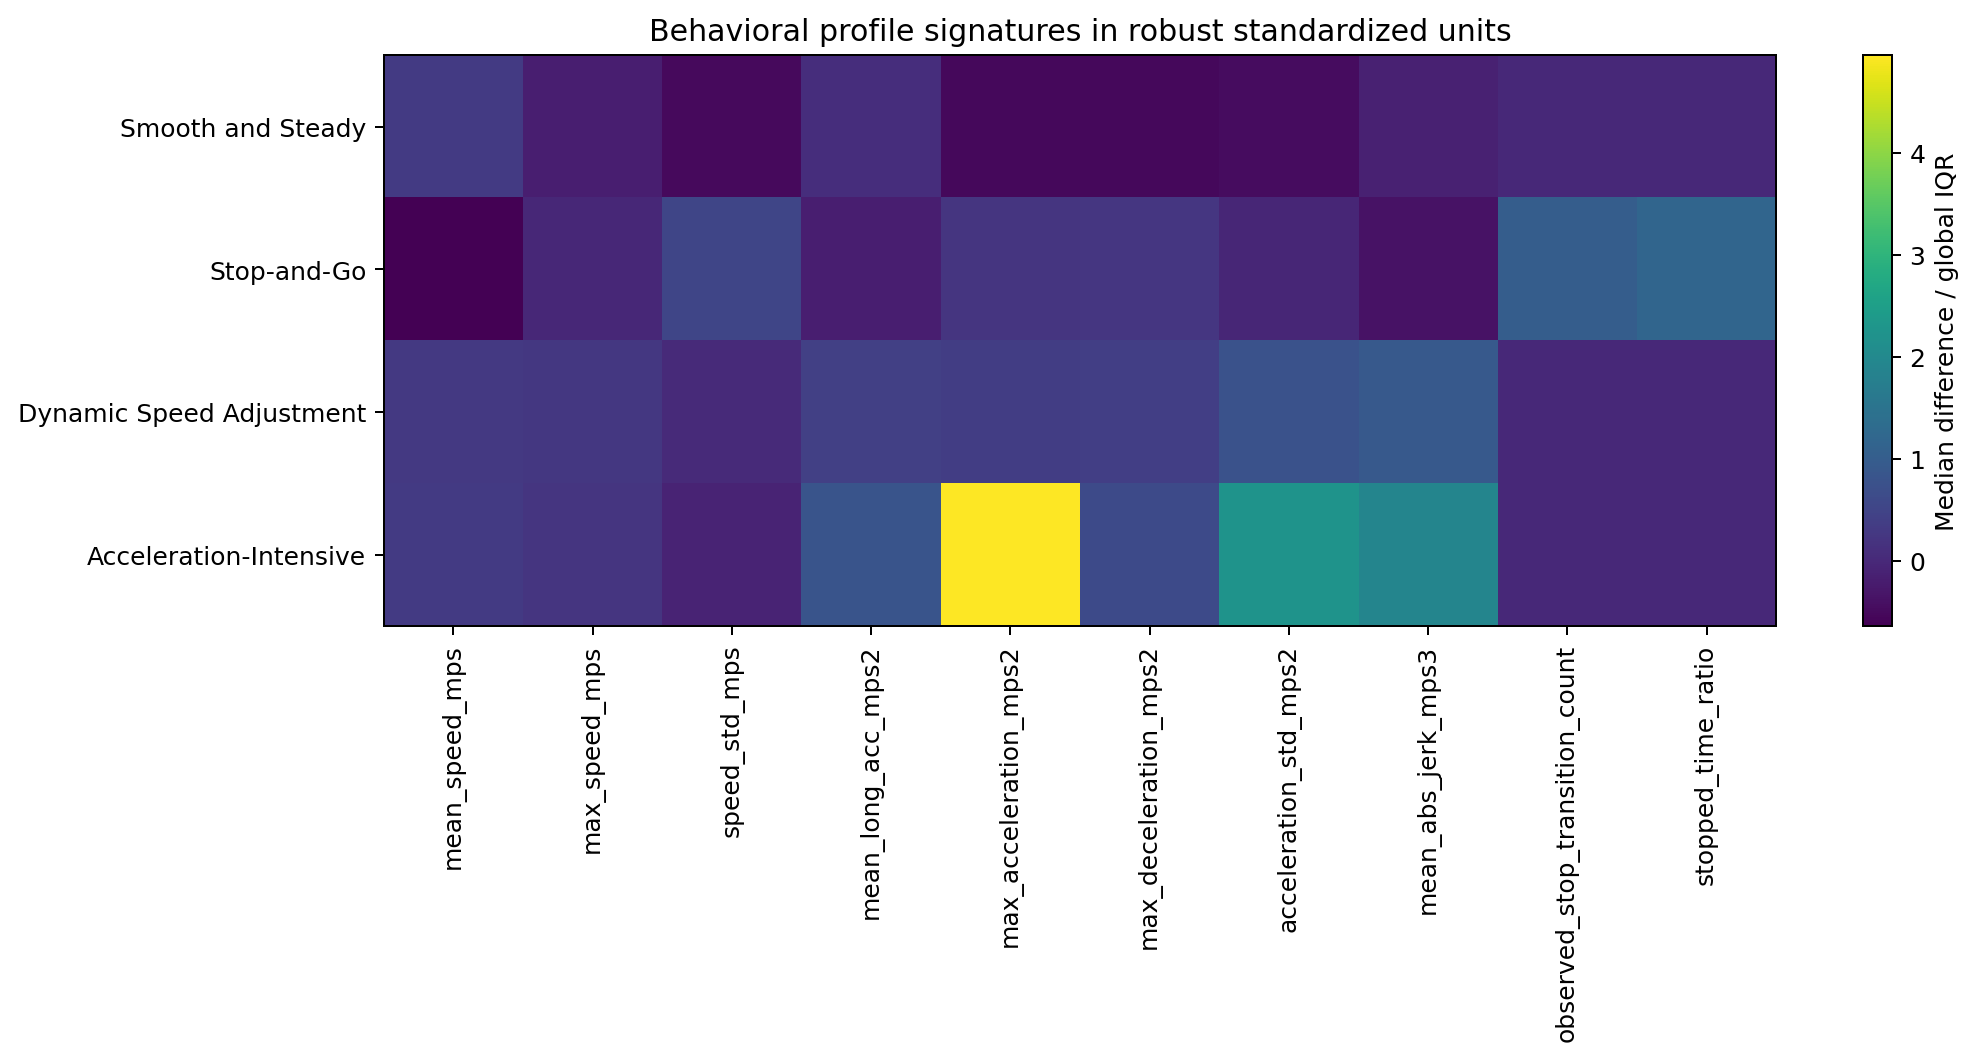

In [3]:

display(Image(filename=str(
    FIGURES / "stage7_profile_robust_score_heatmap.png"
)))



## 2. Representative trajectories

Each example is the observed trajectory nearest to the corresponding K-Means
centroid in five-dimensional PCA space.


In [4]:

representatives[
    [
        "profile_id",
        "profile_name",
        "trajectory_uid",
        "city",
        "recording_id",
        "track_id",
        "distance_to_centroid",
    ]
]


,profile_id,profile_name,trajectory_uid,city,recording_id,track_id,distance_to_centroid
0,1,Smooth and Steady,Xi'an__xian_412_n3__341,Xi'an,xian_412_n3,341,0.158940
1,2,Stop-and-Go,Xi'an__xian_412_m2__31,Xi'an,xian_412_m2,31,0.169090
2,3,Dynamic Speed Adjustment,Chongqing__6_29_NR_2__165,Chongqing,6_29_NR_2,165,0.251415
3,4,Acceleration-Intensive,Changchun__changchun_pudong_507_009__359,Changchun,changchun_pudong_507_009,359,0.585329



## 3. Tianjin-only metadata interpretation

The signal-violation rate is not a model accuracy measure. It is a
post-cluster descriptive association available only for Tianjin.


In [5]:

violation


,profile_id,profile_name,tianjin_trajectories,violations,violation_rate,violation_rate_pct,wilson_95_lower,wilson_95_upper,relative_to_overall
0,1,Smooth and Steady,2527,91,0.036011,3.601108,0.029422,0.044008,1.182886
1,2,Stop-and-Go,1127,11,0.009760,0.976043,0.005459,0.017393,0.320609
2,3,Dynamic Speed Adjustment,633,26,0.041074,4.107425,0.028182,0.059503,1.349200
3,4,Acceleration-Intensive,246,10,0.040650,4.065041,0.022228,0.073198,1.335277


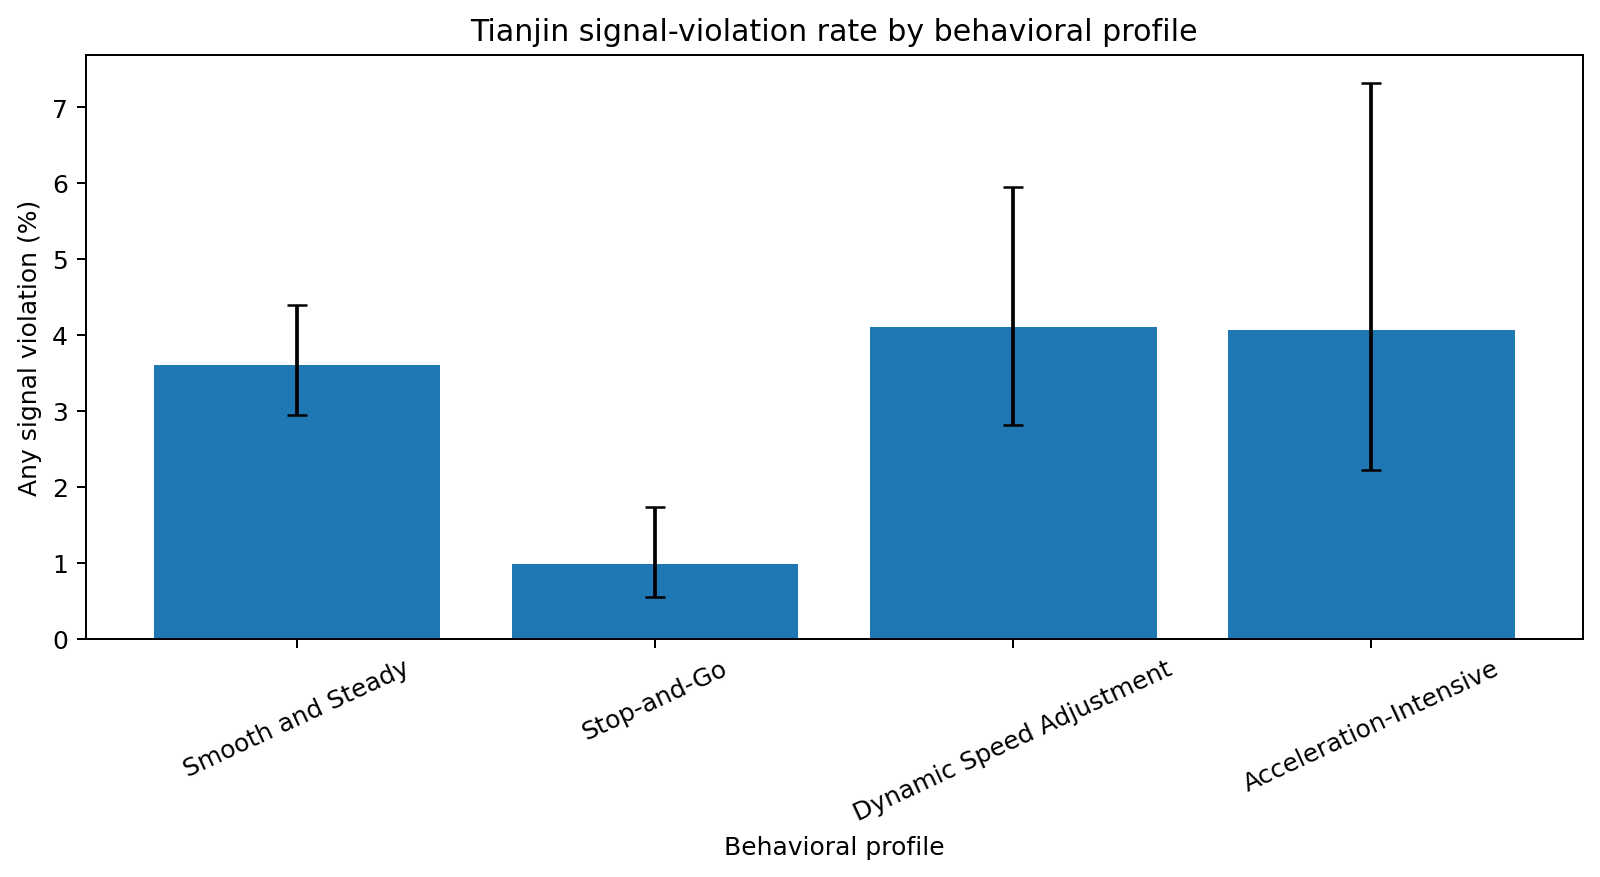

In [6]:

display(Image(filename=str(
    FIGURES / "stage7_tianjin_violation_rate_by_profile.png"
)))



## 4. Decision-support matrix

The dimensions are relative operational-attention rankings, not crash-risk
probabilities.


In [7]:

attention


,profile_id,profile_name,dynamic_maneuver_priority,signal_queue_priority,speed_adjustment_priority,tianjin_violation_rate_pct,tianjin_violation_enrichment,attention_tier,recommended_operational_focus,interpretation_warning
0,1,Smooth and Steady,31.25,50.0,25.000000,3.601108,1.182886,Baseline reference,Use as the baseline flow profile; monitor prev...,Descriptive attention priority only; not a cra...
1,2,Stop-and-Go,43.75,100.0,66.666667,0.976043,0.320609,Operational priority,"Review signal timing, queue formation, stop fr...",Descriptive attention priority only; not a cra...
2,3,Dynamic Speed Adjustment,75.00,50.0,83.333333,4.107425,1.349200,High review priority,"Review approach-speed consistency, braking zon...",Descriptive attention priority only; not a cra...
3,4,Acceleration-Intensive,100.00,50.0,75.000000,4.065041,1.335277,High review priority,Prioritize trajectory-quality verification and...,Descriptive attention priority only; not a cra...


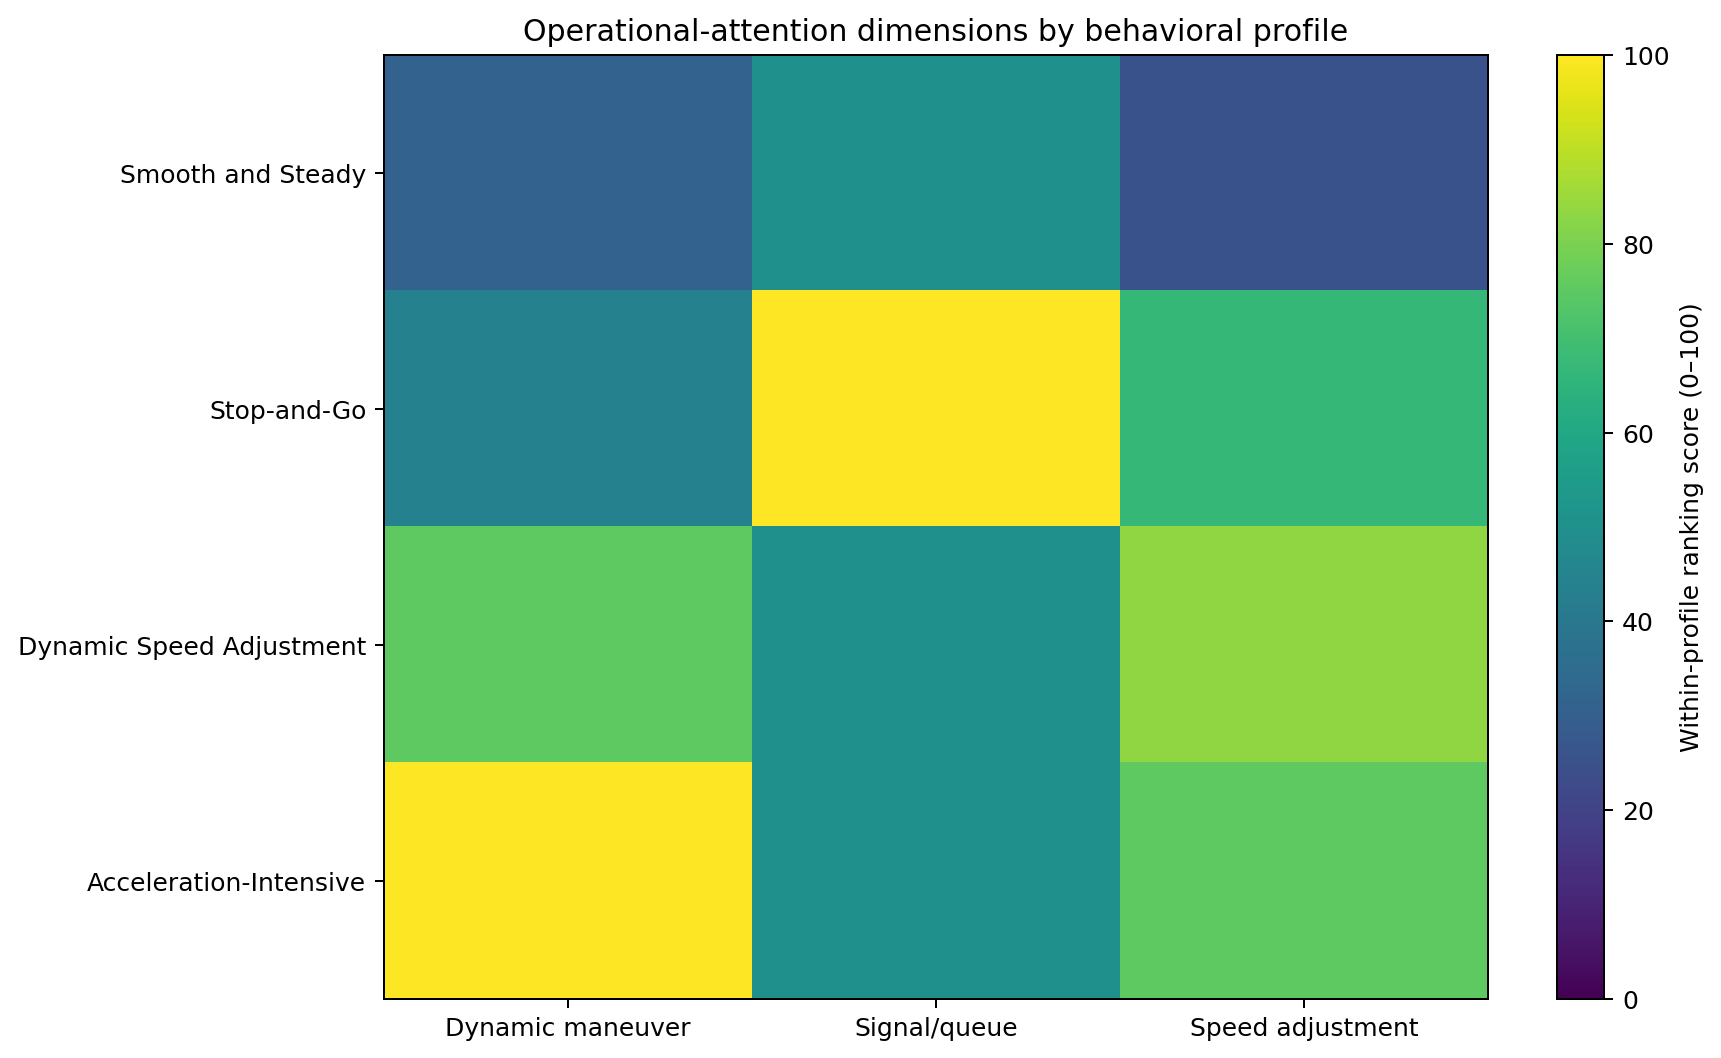

In [8]:

display(Image(filename=str(
    FIGURES / "stage7_attention_dimension_heatmap.png"
)))



## Conclusion

The final framework supports behavioral monitoring, context comparison, and
review prioritization. It does not establish causal safety risk or replace
expert traffic-engineering review.
